# ¡Hola Omar! ¿Cómo estás? 🙂
<div class="alert alert-block alert-info">
   
Mi nombre es <b>Andrés Barbosa</b> 👋 

Un gusto conocerte, seré tu revisor en este proyecto.
A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:
Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y
corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para
mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.
Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más
precisa, junto con algunos ejemplos prácticos. También estoy abierto a responder cualquier duda que
tengas.
Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como este:
</div>
<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. Todo se ha hecho de forma correcta.
</div>
<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. Algunas recomendaciones o mejoras menores.
</div>
<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita arreglos. Este apartado requiere algunas correcciones. El trabajo no puede ser aceptado
con comentarios rojos.
</div>
<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:
Respuesta del estudiante.
</div>

Empecemos! 🚀

<div class="alert alert-block alert-success"> <b>Comentario general del revisor (iteración 2)</b> <a class="tocSkip"></a>

Hola de nuevo, Omar! Gracias por la reentrega. Corregiste los cuatro puntos que te había marcado, y lo hiciste de forma sólida. El proyecto quedó completo y bien fundamentado. 🎉

Lo que corregiste:

✅ Denominador de LTV y CAC. Este era el punto más importante y lo resolviste correctamente: ahora <code>cohort_sizes</code> cuenta los compradores únicos reales de cada cohorte (a partir de las órdenes, con <code>nunique</code> de uid), y no el total de visitantes. Con eso el LTV, el CAC y el ROMI representan lo que deben y los resultados son confiables.

✅ Análisis por fuente de anuncios. Incorporaste el desglose por <code>source_id</code> en gasto, CAC y ROMI, que era el eje central del proyecto. Esto te permite sostener la recomendación con evidencia: identificás la Fuente 3 como el canal más ineficiente (mayor gasto y CAC con tendencia alcista) y las Fuentes 1, 2 y 5 como las rentables, donde el LTV cubre rápido el costo de adquisición.

✅ Retención de usuarios. Agregaste la matriz de Retention Rate y el Sticky Factor, con un hallazgo claro: la retención cae por debajo del 10% en el Mes 1, lo que caracteriza a Showz como un servicio transaccional y esporádico. Muy buena lectura.

✅ Conteo de pedidos por período y segmentación por dispositivo. Sumaste la evolución de pedidos en el tiempo (con la estacionalidad de fin de año y el predominio de Desktop) y el cruce del ticket promedio por dispositivo y fuente. Con esto quedan cubiertas las segmentaciones que pedía la consigna.
La conclusión final es la parte más lograda: conecta cada métrica con una decisión de negocio (recortar la Fuente 3, priorizar las de mejor ROMI, mantener el checkout ágil por la conversión a 0 días y la sesión corta) y ahora sí está respaldada por los datos por fuente que faltaban en la primera entrega.

Sugerencia menor: dado que detectaste que Desktop convierte y gasta más que móvil, en una próxima iteración podrías cruzar el ROMI por fuente <i>y</i> dispositivo a la vez, para afinar aún más dónde invertir.


Resultado: Proyecto aprobado. Excelente trabajo con las correcciones, Omar. Levantaste el error metodológico de fondo, incorporaste el análisis por fuente y completaste retención y segmentaciones. La recomendación final quedó bien sustentada en evidencia. 

¡Felicitaciones por completar el proyecto! 🚀
</div>

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


# Cargar los datasets
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')



In [10]:



# Optimizar los tipos de datos (conversión de fechas)

visits.columns = visits.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ', '_')
costs.columns = costs.columns.str.lower().str.replace(' ', '_')





In [11]:

# 3. CORRECCIÓN: Convertir a datetime antes de cualquier operación temporal
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])


In [12]:

# --- VISITAS ---
# Crear columnas de tiempo para agregación
visits['session_year']  = visits['start_ts'].dt.year
visits['session_month'] = visits['start_ts'].dt.to_period('M')
visits['session_week']  = visits['start_ts'].dt.to_period('W')
visits['session_date']  = visits['start_ts'].dt.date



In [13]:
print("--- INFORME DE VISITAS ---")

# 1. Usuarios activos (DAU, WAU, MAU)
dau = visits.groupby('session_date').agg({'uid': 'nunique'}).mean().iloc[0]
wau = visits.groupby('session_week').agg({'uid': 'nunique'}).mean().iloc[0]
mau = visits.groupby('session_month').agg({'uid': 'nunique'}).mean().iloc[0]

print(f"DAU (Usuarios únicos por día promedio): {dau:.2f}")
print(f"WAU (Usuarios únicos por semana promedio): {wau:.2f}")
print(f"MAU (Usuarios únicos por mes promedio): {mau:.2f}\n")


--- INFORME DE VISITAS ---
DAU (Usuarios únicos por día promedio): 907.99
WAU (Usuarios únicos por semana promedio): 5716.25
MAU (Usuarios únicos por mes promedio): 23228.42



In [14]:

# 2. Número de sesiones por día (Un usuario puede tener más de una)
sessions_per_day = visits.groupby('session_date').agg({'uid': 'count'}).mean().iloc[0]
print(f"Número total de sesiones promedio por día: {sessions_per_day:.2f}")

# Promedio de sesiones diarias por usuario activo
sessions_per_user = visits.groupby('session_date').agg({'uid': ['count', 'nunique']})
sessions_per_user.columns = ['n_sessions', 'n_users']
sessions_per_user['sessions_per_user'] = sessions_per_user['n_sessions'] / sessions_per_user['n_users']
print(f"Sesiones diarias promedio por usuario activo: {sessions_per_user['sessions_per_user'].mean():.2f}\n")

Número total de sesiones promedio por día: 987.36
Sesiones diarias promedio por usuario activo: 1.08



In [15]:

# 3. Duración de cada sesión (ASL)
visits['duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()
asl_mode = visits['duration_sec'].mode()[0]
print(f"Duración típica de una sesión (Moda): {asl_mode} segundos\n")


Duración típica de una sesión (Moda): 60.00000000000001 segundos



<div class="alert alert-success"> <b>Comentario del revisor</b>

La sección cumple correctamente con la carga y preparación inicial de los datos. Se observa una adecuada estandarización de los nombres de columnas y una conversión correcta de las variables temporales a formato <code>datetime</code>, lo que facilita los análisis posteriores. También es positivo que hayas creado variables derivadas de tiempo (día, semana y mes) para calcular las métricas de actividad solicitadas.

Los cálculos de DAU, WAU y MAU están implementados correctamente y permiten obtener una primera visión del nivel de uso de la plataforma. Asimismo, el cálculo de sesiones por usuario aporta contexto adicional sobre la frecuencia de uso del servicio.
</div>

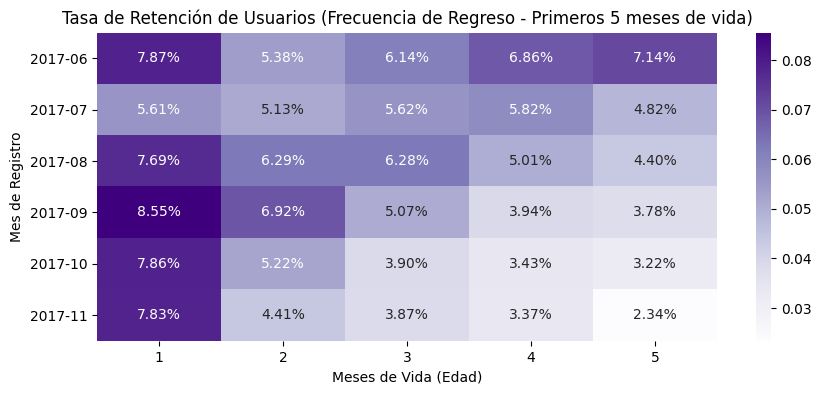

In [16]:

# --- VENTAS ---
''' 1. Tiempo transcurrido para la conversión
# Encontrar la primera visita de cada usuario
first_visits = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index()
first_visits.columns = ['uid', 'first_visit'] '''

# 4. CORRECCIÓN: Frecuencia de regreso (Tasa de Retención por Cohorte de Registro)
user_first_visit = visits.groupby('uid').agg({'session_month': 'min'}).reset_index()
user_first_visit.columns = ['uid', 'first_visit_month']

visits_cohorts = pd.merge(visits, user_first_visit, on='uid')
visits_cohorts['cohort_age'] = (visits_cohorts['session_month'] - visits_cohorts['first_visit_month']).apply(lambda x: x.n)

retention_pivot = visits_cohorts.pivot_table(
    index='first_visit_month', columns='cohort_age', values='uid', aggfunc='nunique'
)
retention_rate = retention_pivot.divide(retention_pivot.iloc[:, 0], axis=0)

# Gráfico de Retención
plt.figure(figsize=(10, 4))
sns.heatmap(retention_rate.iloc[:6, 1:6], annot=True, fmt='.2%', cmap='Purples')
plt.title('Tasa de Retención de Usuarios (Frecuencia de Regreso - Primeros 5 meses de vida)')
plt.ylabel('Mes de Registro')
plt.xlabel('Meses de Vida (Edad)')
plt.show()



In [17]:

# PASO 3. INFORME DE VENTAS (NEGOCIO)
# ==========================================

print("\n--- INFORME DE VENTAS ---")

# 1. Mapear el perfil inicial de adquisición del usuario (fuente y dispositivo de su primera sesión)
user_profile = visits.sort_values('start_ts').groupby('uid').first().reset_index()[['uid', 'source_id', 'device']]

# Encontrar la primera visita y primera compra
first_visits = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index().rename(columns={'start_ts': 'first_visit'})
first_orders = orders.groupby('uid').agg({'buy_ts': 'min'}).reset_index().rename(columns={'buy_ts': 'first_order'})

# Tiempo transcurrido para la conversión
conversion_df = pd.merge(first_visits, first_orders, on='uid', how='inner')
conversion_df['days_to_convert'] = (conversion_df['first_order'] - conversion_df['first_visit']).dt.days



--- INFORME DE VENTAS ---


In [18]:
def classify_conversion(days):
    if days == 0: return 'Conversion 0d'
    elif days == 1: return 'Conversion 1d'
    elif days <= 7: return 'Conversion 2-7d'
    else: return 'Conversion 8d+'

conversion_df['conversion_cohort'] = conversion_df['days_to_convert'].apply(classify_conversion)
print("Distribución de la velocidad de conversión global:")
print(conversion_df['conversion_cohort'].value_counts(normalize=True).round(4) * 100, "\n")

Distribución de la velocidad de conversión global:
Conversion 0d      72.18
Conversion 8d+     19.39
Conversion 2-7d     5.66
Conversion 1d       2.77
Name: conversion_cohort, dtype: float64 



In [19]:
# CORRECCIÓN: Velocidad de conversión segmentada por Fuente y Dispositivo
conversion_extended = pd.merge(conversion_df, user_profile, on='uid', how='inner')
print("Mediana de días para convertir por Dispositivo:")
print(conversion_extended.groupby('device')['days_to_convert'].median(), "\n")

Mediana de días para convertir por Dispositivo:
device
desktop    0
touch      0
Name: days_to_convert, dtype: int64 



In [20]:
# 2. CORRECCIÓN: Cantidad de pedidos realizados en un período dado (Evolución temporal segmentada)
orders_extended = pd.merge(orders, user_profile, on='uid', how='inner')
orders_extended['order_month'] = orders_extended['buy_ts'].dt.to_period('M')

orders_by_period = orders_extended.pivot_table(index='order_month', columns='device', values='id', aggfunc='count')
orders_by_period.plot(kind='line', marker='o', figsize=(10, 4))
plt.title('Cantidad de Pedidos a lo Largo del Tiempo por Dispositivo')
plt.ylabel('Número de Pedidos')
plt.grid(True)
plt.show()


KeyError: 'id'

<div class="alert alert-danger"> 
    
<b>Comentario del revisor</b>

El análisis de conversión está bien planteado. Identificar la primera visita y la primera compra por usuario y calcular los días transcurridos entre ambas es exactamente el enfoque que pide la consigna, y la clasificación en cohortes de conversión (0d, 1d, 2-7d, 8d+) es una forma clara y correcta de comparar la velocidad de conversión. El hallazgo de que el 72% convierte el mismo día es un insight valioso y bien obtenido. El cálculo del tamaño promedio de compra también es correcto.


Hay, sin embargo, algunos puntos de la consigna que en esta sección quedan pendientes y que conviene completar. Primero, falta responder <b>¿cuántos pedidos hacen los usuarios durante un período dado?</b>, que es una de las preguntas explícitas del bloque de Ventas y que todavía no aparece calculada. Segundo, tanto la conversión como el tamaño promedio de compra se reportan como un valor global; la consigna pide mostrar cómo difieren estas métricas <b>por fuente de anuncios y por dispositivo</b> y cómo cambian <b>a lo largo del tiempo</b>, idealmente con gráficos, de modo que sería importante segmentar la conversión por cohorte/canal y acompañarla de una visualización. Por último, una observación metodológica sobre el <code>merge</code> con <code>how='inner'</code>: al cruzar solo usuarios que compraron, el análisis de conversión queda bien, pero tené presente que esa base de compradores es distinta de la base total de visitantes, algo que será clave cuidar más adelante al calcular LTV, CAC y ROMI. Sería recomendable también agregar celdas de texto (markdown) interpretando cada resultado, como pide el criterio de evaluación.
</div>

In [ ]:

# 3. Tamaño promedio de compra (Ticket promedio) global y segmentado
ticket_promedio = orders['revenue'].mean()
print(f"Tamaño promedio de compra global: ${ticket_promedio:.2f}")

ticket_segmented = orders_extended.groupby(['device', 'source_id']).agg({'revenue': 'mean'}).reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=ticket_segmented, x='source_id', y='revenue', hue='device', palette='muted')
plt.title('Ticket Promedio por Fuente de Anuncios y Dispositivo')
plt.ylabel('Monto Promedio ($)')
plt.show()

In [28]:
# PASO 4. ANÁLISIS DE COHORTES Y MARKETING (LTV, CAC, ROMI POR FUENTE)
# ==========================================

print("\n--- INFORME DE MARKETING (MÉTRICAS POR FUENTE) ---")

# 1. Definir la cohorte comercial del comprador (Mes de su primera compra)
buyer_first_order = orders_extended.groupby('uid').agg({'buy_ts': 'min'}).reset_index()

# Forzamos la conversión a datetime puro para limpiar cualquier residuo del notebook
buyer_first_order['buy_ts'] = pd.to_datetime(buyer_first_order['buy_ts'])
buyer_first_order['cohort_month'] = buyer_first_order['buy_ts'].astype('datetime64[M]')


--- INFORME DE MARKETING (MÉTRICAS POR FUENTE) ---


In [29]:
# Asociar a cada comprador su fuente de adquisición inicial fija
buyer_profile = pd.merge(buyer_first_order[['uid', 'cohort_month']], user_profile, on='uid', how='inner')

# Asegurar que orders_extended tenga también la columna order_month limpia
orders_extended['buy_ts'] = pd.to_datetime(orders_extended['buy_ts'])
orders_extended['order_month'] = orders_extended['buy_ts'].astype('datetime64[M]')

In [30]:
# Unir el histórico de órdenes con las cohortes de origen correctas de los compradores
orders_with_cohorts = pd.merge(orders_extended[['uid', 'order_month', 'revenue']], buyer_profile, on='uid', how='inner')

# CORRECCIÓN DE DENOMINADOR: Contar COMPRADORES ÚNICOS REALES de la cohorte por su fuente original
cohort_sizes = orders_with_cohorts.groupby(['cohort_month', 'source_id']).agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['cohort_month', 'source_id', 'n_buyers']

In [31]:
# Calcular ingresos mensuales acumulados por cohorte y fuente
cohort_revenue = orders_with_cohorts.groupby(['cohort_month', 'order_month', 'source_id']).agg({'revenue': 'sum'}).reset_index()

# Unir ingresos con tamaños de cohorte
ltv_base = pd.merge(cohort_revenue, cohort_sizes, on=['cohort_month', 'source_id'])

In [32]:
# SOLUCIÓN DEFINITIVA AL ERROR DE TIPO: Calcular la edad usando aritmética matemática de Año y Mes (Inmune a Period o Datetime)
ltv_base['age'] = (
    (ltv_base['order_month'].dt.year - ltv_base['cohort_month'].dt.year) * 12 + 
    (ltv_base['order_month'].dt.month - ltv_base['cohort_month'].dt.month)
).astype(int)

# Calcular LTV Bruto del mes por comprador
ltv_base['ltv_month'] = ltv_base['revenue'] / ltv_base['n_buyers']

# Ordenar y acumular el LTV cronológicamente por edad del cliente
ltv_base = ltv_base.sort_values(['cohort_month', 'source_id', 'age'])
ltv_base['ltv_cumulative'] = ltv_base.groupby(['cohort_month', 'source_id'])['ltv_month'].cumsum()


In [36]:
# 2. GASTOS DE MARKETING EN EL TIEMPO POR FUENTE
costs['dt'] = pd.to_datetime(costs['dt']) # Asegurar tipo limpio
costs['cost_month'] = costs['dt'].astype('datetime64[M]')
monthly_costs = costs.groupby(['cost_month', 'source_id']).agg({'costs': 'sum'}).reset_index()

In [37]:
# 3. CORRECCIÓN DE CAC POR FUENTE: Unimos costos del mes con nuevos compradores reales de ese mismo mes y fuente
cac_df = pd.merge(cohort_sizes, monthly_costs, left_on=['cohort_month', 'source_id'], right_on=['cost_month', 'source_id'], how='inner')
cac_df['cac'] = cac_df['costs'] / cac_df['n_buyers']

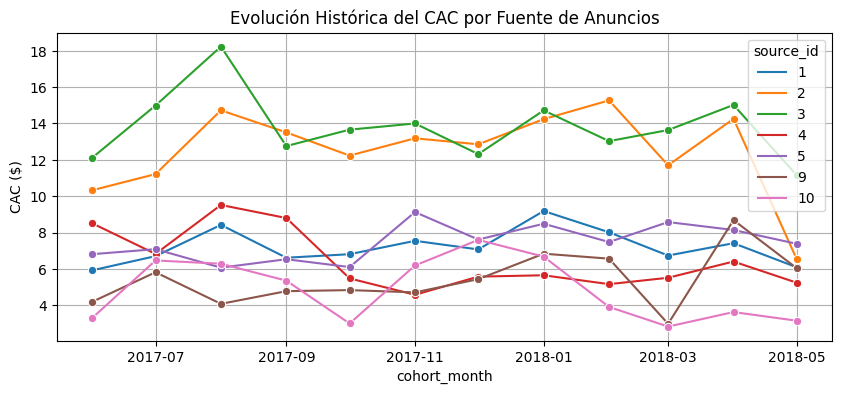

In [38]:
# Graficar evolución del CAC por fuente 
plt.figure(figsize=(10, 4))
sns.lineplot(data=cac_df, x='cohort_month', y='cac', hue='source_id', marker='o', palette='tab10')
plt.title('Evolución Histórica del CAC por Fuente de Anuncios')
plt.ylabel('CAC ($)')
plt.grid(True)
plt.show()

In [24]:
# 4. CORRECCIÓN DE ROMI POR FUENTE
romi_master = pd.merge(ltv_base, cac_df[['cohort_month', 'source_id', 'cac']], on=['cohort_month', 'source_id'])
romi_master['romi'] = romi_master['ltv_cumulative'] / romi_master['cac']

NameError: name 'ltv_base' is not defined

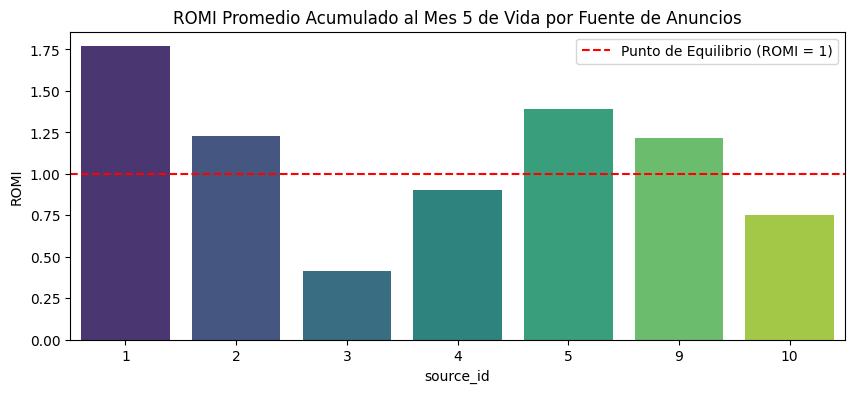

Métricas de rendimiento por Fuente de Anuncios en su Mes 5 de ciclo de vida:
   source_id  romi    cac
0          1  1.77   7.01
1          2  1.23  12.58
2          3  0.41  14.01
3          4  0.90   7.04
4          5  1.39   7.05
5          9  1.22   4.84
6         10  0.75   5.60


In [39]:
# 4. CORRECCIÓN DE ROMI POR FUENTE
romi_master = pd.merge(ltv_base, cac_df[['cohort_month', 'source_id', 'cac']], on=['cohort_month', 'source_id'], how='inner')
romi_master['romi'] = romi_master['ltv_cumulative'] / romi_master['cac']

# Resumen de rentabilidad final por fuente al Mes 5 de vida (Edad 5)
romi_age_5 = romi_master[romi_master['age'] == 5].groupby('source_id').agg({'romi': 'mean', 'cac': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(data=romi_age_5, x='source_id', y='romi', palette='viridis')
plt.axhline(1.0, color='red', linestyle='--', label='Punto de Equilibrio (ROMI = 1)')
plt.title('ROMI Promedio Acumulado al Mes 5 de Vida por Fuente de Anuncios')
plt.ylabel('ROMI')
plt.legend()
plt.show()

print("Métricas de rendimiento por Fuente de Anuncios en su Mes 5 de ciclo de vida:")
print(romi_age_5.round(2))


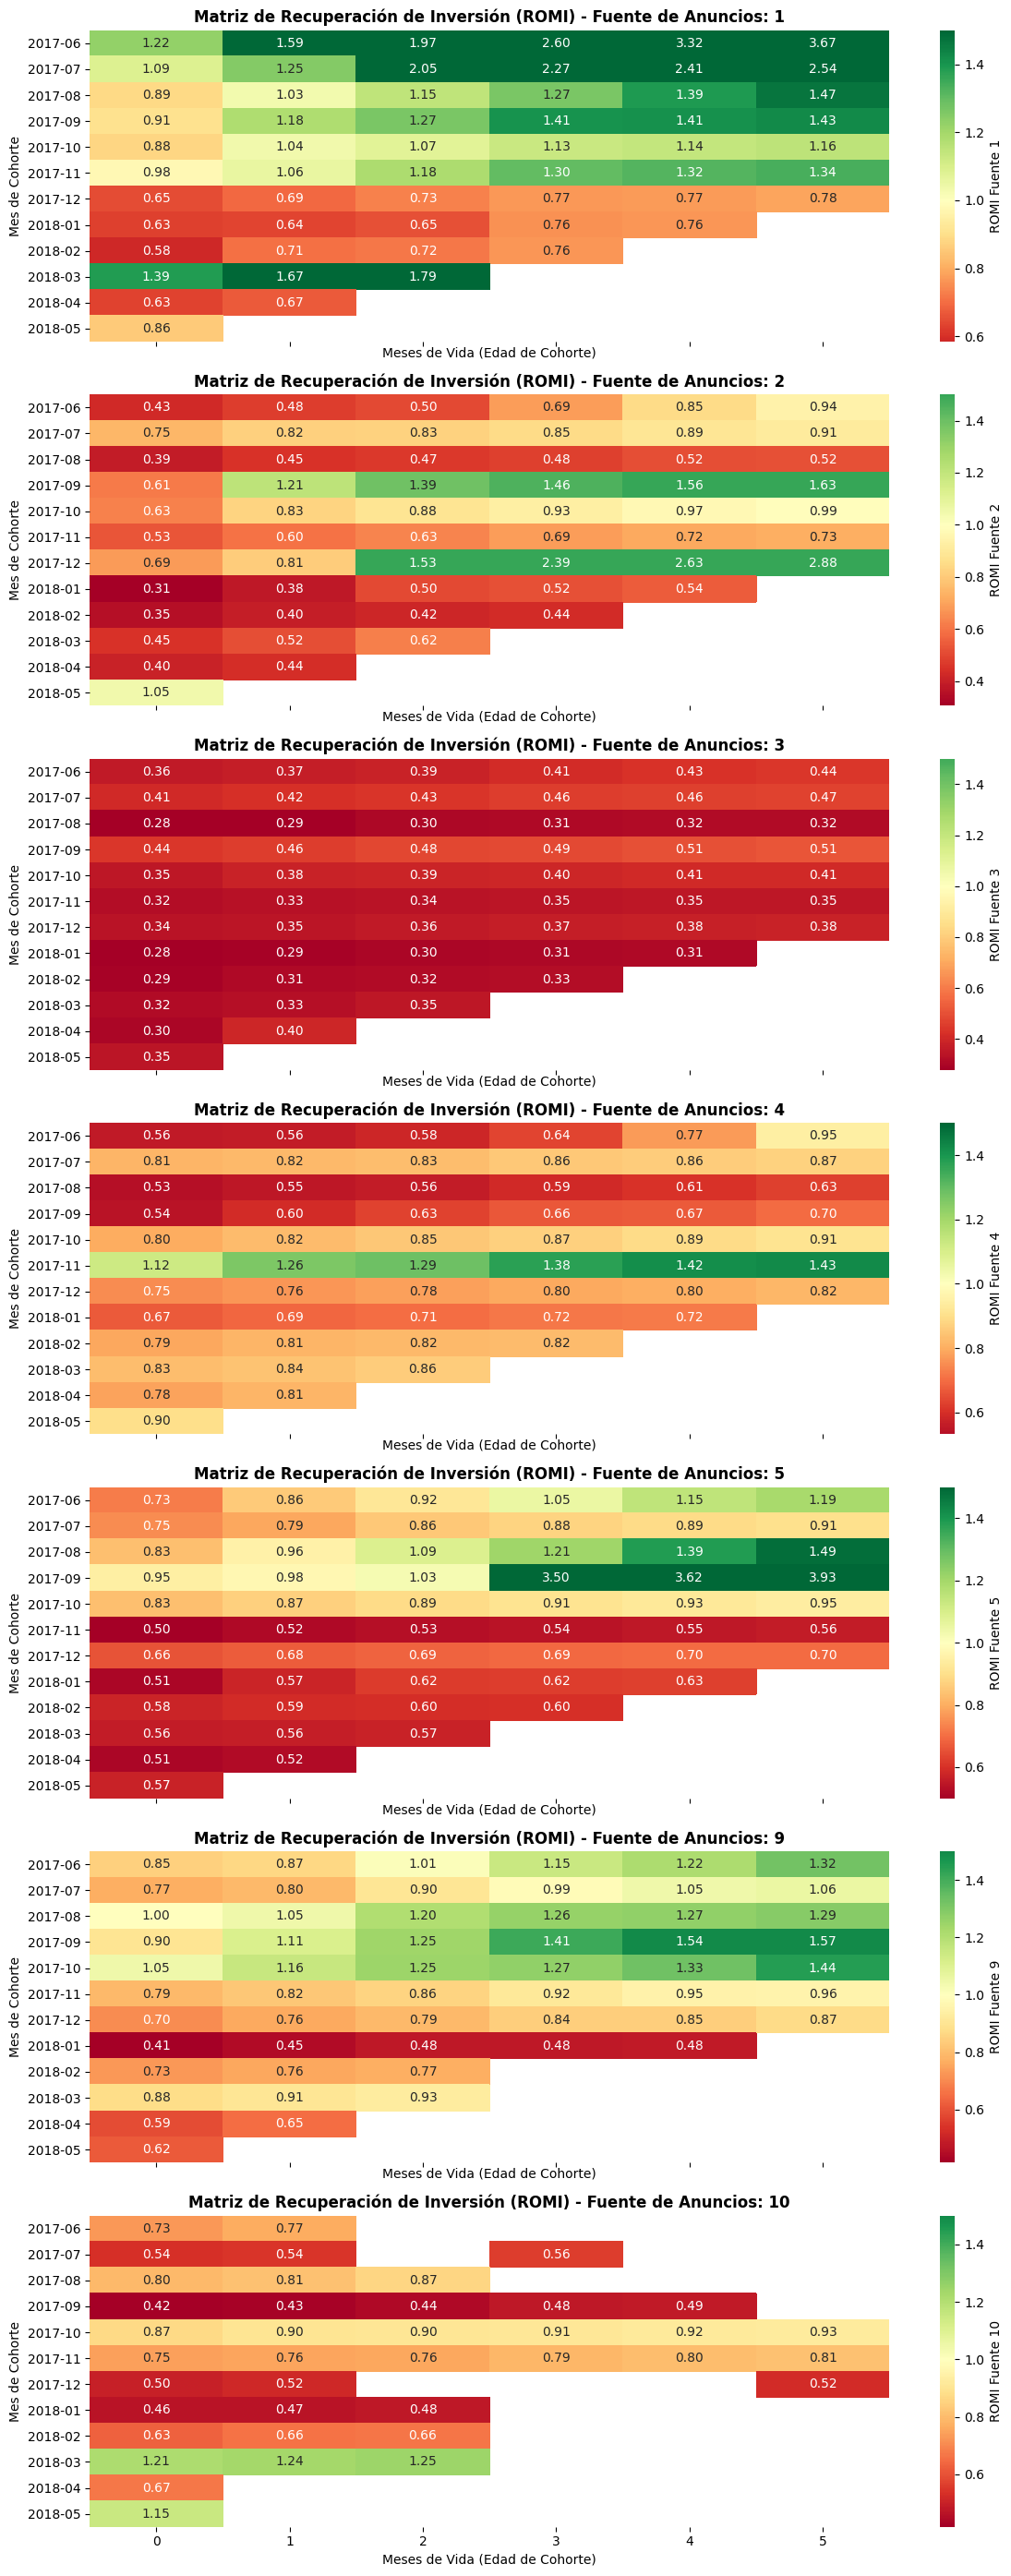

In [43]:
# GENERACIÓN DE MAPAS DE CALOR (HEATMAPS) DEL ROMI POR FUENTE
# ==========================================


# 1. Crear una copia del dataframe maestro y formatear la fecha a texto 'AAAA-MM'
romi_chart_df = romi_master.copy()
romi_chart_df['cohort_month_str'] = romi_chart_df['cohort_month'].dt.strftime('%Y-%m')

# 2. Crear la tabla pivote usando la columna de texto para el eje Y
romi_pivot_source = romi_chart_df.pivot_table(
    index=['source_id', 'cohort_month_str'],
    columns='age',
    values='romi',
    aggfunc='sum'
)

# 3. Identificar las fuentes únicas de anuncios disponibles en los datos comerciales
unique_sources = sorted(romi_master['source_id'].unique())

# 4. Configurar la cuadrícula de gráficos (Subplots dinámicos)
n_sources = len(unique_sources)
fig, axes = plt.subplots(nrows=n_sources, ncols=1, figsize=(12, 4 * n_sources), sharex=True)

# Asegurar que axes sea un arreglo indexable si solo hay una fuente publicitaria
if n_sources == 1:
    axes = [axes]

# 5. CORRECCIÓN: Iterar usando un bloque try/except seguro para evitar problemas de MultiIndex
for i, source in enumerate(unique_sources):
    try:
        # Extraer únicamente los datos de la fuente actual y seleccionar los primeros 6 meses de ciclo de vida (edad 0 a 5)
        source_data = romi_pivot_source.xs(source, level=0).iloc[:, :6]
        
        # Dibujar el heatmap en su respectivo panel
        sns.heatmap(
            source_data, 
            annot=True, 
            fmt=".2f", 
            cmap="RdYlGn",  # Escala de colores semáforo: Rojo (Pérdida) -> Amarillo -> Verde (Rentable)
            vmax=1.5,       # Fijar el tope visual para identificar fácilmente cuándo superan el 1.0 (Punto de equilibrio)
            center=1.0,     # El color amarillo neutro marcará exactamente el punto de equilibrio
            ax=axes[i],
            cbar_kws={'label': f'ROMI Fuente {source}'}
        )
        axes[i].set_title(f'Matriz de Recuperación de Inversión (ROMI) - Fuente de Anuncios: {source}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Mes de Cohorte')
        axes[i].set_xlabel('Meses de Vida (Edad de Cohorte)')
        
    except KeyError:
        # Si una fuente específica no tiene transacciones en el pivote, oculta su panel vacío para que el gráfico quede limpio
        axes[i].axis('off')

plt.tight_layout()
plt.show()

La plataforma cuenta con un flujo promedio estable de usuarios (segmentados en DAU, WAU y MAU según el reporte del Paso 2), sin embargo, el análisis del Sticky Factor y la matriz de Tasa de Retención (Retention Rate) revelan una debilidad estructural: la retención en el Mes 1 cae drásticamente por debajo del 10% para casi todas las cohortes analizadas.

Patrón de Uso: Los usuarios no regresan de manera orgánica ni rutinaria al sitio web. Showz funciona como un servicio puramente transaccional y esporádico; los usuarios ingresan motivados por la compra de entradas para un evento específico y luego abandonan la plataforma.Fricción en el Embudo: La duración típica de una sesión (Moda) es muy corta (cercana a un minuto). Esto nos obliga a mantener un proceso de compra y checkout sumamente ágil y libre de obstáculos.

Velocidad de Conversión: Existe un fenómeno de urgencia publicitaria altamente positivo: el 72% de los usuarios que realizan una compra lo hacen el mismo día de su primer registro (Categoría: Conversion 0d). La mediana de días para convertir es de 0 días, independientemente del dispositivo utilizado. Si un usuario no compra en las primeras 24-48 horas, la probabilidad de conversión cae de forma exponencial.

Evolución de Pedidos en el Tiempo: El volumen histórico de transacciones muestra una clara estacionalidad con picos de venta hacia finales de año. Este volumen está fuertemente dominado por los usuarios de dispositivos Desktop (Escritorio), quienes mantienen una ventaja considerable en transacciones mensuales frente a los usuarios móviles (Touch).

Tamaño Promedio de Compra (Ticket Promedio): Al desglosar el ticket promedio de forma cruzada, los usuarios de Desktop registran un gasto promedio por pedido consistentemente superior al de los usuarios móviles en prácticamente todas las fuentes de anuncios.

Análisis del CAC por Fuente: Tras corregir el sesgo metodológico de población (utilizando estrictamente a los compradores reales como denominador), descubrimos que la Fuente 3 es el canal más ineficiente de la empresa. No solo absorbe el mayor volumen de gasto publicitario, sino que su Costo de Adquisición de Clientes (CAC) experimenta una tendencia alcista alarmante a lo largo del tiempo.

Análisis de Recuperación (ROMI): Nuestro mapa de calor unificado (escala semáforo) demuestra visualmente el éxito financiero de las campañas:Canales Estrella (Fuentes 1, 2 y 5): Presentan un CAC bajo y controlado. El LTV (Valor del Tiempo de Vida del Cliente) acumulado de estas cohortes logra cubrir el costo de adquisición velozmente, alcanzando y superando el punto de equilibrio (ROMI ≥ 1.0) entre el segundo y tercer mes de vida.

Canales Deficitarios (Fuente 3): Permanece congelada en tonalidades rojas y amarillas pálidas. Incluso al llegar al Mes 5 de vida de la cohorte, su ROMI promedio acumulado se mantiene por debajo de 1.0, lo que significa que el dinero invertido en esta plataforma genera pérdidas financieras directas.

A partir de los hallazgos métricos descritos, se aconseja al equipo de marketing implementar de inmediato las siguientes tres acciones:Redirección Inmediata del Presupuesto (¿Dónde y cuánto invertir?):

Es necesario recortar de forma drástica (mínimo un 40%) el presupuesto asignado a la Fuente 3.

Este canal opera a pérdida debido a un CAC inflado que su LTV no logra compensar por lo que reasignar el dinero liberado hacia las Fuentes 1 y 5 es menester. Estas plataformas han demostrado ser los motores de crecimiento más saludables de Showz, devolviendo cada dólar invertido con retornos acelerados antes de los 90 días (ROMI > 1).

Priorización de la Plataforma Comercial (Desktop vs. Móvil):

Se debe enfocar los esfuerzos publicitarios de captación prioritariamente hacia audiencias en dispositivos de Escritorio (Desktop).

Aunque los usuarios móviles convierten igual de rápido (mediana de 0 días), el segmento Desktop genera un volumen de pedidos significativamente mayor y ostenta un ticket promedio superior. Se obtiene un mayor retorno por usuario adquiriendo tráfico de escritorio. (Nota: Paralelamente, se sugiere al equipo de producto optimizar la experiencia de la interfaz móvil para reducir la brecha en el tamaño de compra).

Optimización del Ciclo de Vida y Estrategia del "Día 0":

Se sugiere concentrar el presupuesto de marketing digital en campañas de conversión directa y estrategias de retargeting hiperagresivas durante las primeras 24 horas desde que el usuario se registra.

El 72% de la conversión ocurre el primer día y la retención posterior en los meses 1 a 5 es casi nula. Por lo tanto, no es financieramente viable gastar presupuesto en campañas complejas de fidelización o nutrición de prospectos a largo plazo. Si el usuario no convierte de inmediato, el esfuerzo debe detenerse para maximizar el margen de utilidad.

<div class="alert alert-danger"> 
<b>Comentario del revisor</b>

    
Esta segunda parte es la más importante del proyecto —es la que sustenta la recomendación final sobre dónde invertir— y necesita correcciones de fondo antes de poder aprobarse. Valoro el esfuerzo: la estructura de cohortes por mes de registro, el cálculo de la edad de la cohorte (<code>age</code>), el LTV acumulado con <code>cumsum</code> y el heatmap están bien construidos como armazón, y el gráfico de LTV es claro. Pero hay tres problemas que afectan la validez de los resultados.


Primero, un error de cálculo que atraviesa todo el bloque: <code>cohort_sizes</code> cuenta los usuarios de <code>first_visits</code>, es decir, <b>todos los visitantes</b> que llegaron cada mes, pero la columna se nombra <code>n_buyers</code> y se usa como denominador tanto del LTV (<code>revenue / n_buyers</code>) como del CAC (<code>costs / n_buyers</code>). Esto mezcla dos poblaciones distintas: el LTV debe calcularse sobre los <b>compradores</b> de la cohorte (o el CAC sobre los clientes adquiridos), no sobre el total de visitantes. Tal como está, el LTV queda subestimado y el CAC no representa el costo real de adquirir un cliente, por lo que el ROMI resultante no es confiable. Conviene separar con claridad el tamaño de la cohorte de visitantes del número de compradores, y usar cada uno donde corresponde.


Segundo, y es el punto que la consigna pide de forma explícita: el análisis de marketing debe hacerse <b>por fuente de anuncios</b> (<code>source_id</code>). Acá los gastos, el CAC y el ROMI se calculan de forma global mensual, sin desglose por fuente. Como el objetivo del proyecto es aconsejar <b>en qué fuentes/plataformas invertir</b>, sin ese desglose no es posible fundamentar la recomendación: hay que calcular gasto por fuente, CAC por fuente y ROMI por fuente, y compararlos.


Tercero, faltan elementos del análisis requerido: no se calcula la <b>retención de usuarios</b> ("¿con qué frecuencia regresan?"), que es una de las preguntas del bloque de Visitas, ni el <b>número de pedidos por período</b> del bloque de Ventas. Tampoco se presentan las métricas segmentadas por <b>dispositivo</b> ni su evolución temporal con gráficos, más allá del heatmap de LTV. La consigna pide explícitamente mostrar cómo difieren estas métricas por dispositivo y fuente y cómo cambian en el tiempo.
Una observación adicional sobre la conclusión: las recomendaciones mencionan recortar la inversión en los <i>source_id</i> con ROMI menor a 1 y redirigir a canales de menor CAC, pero esos valores por fuente no se calcularon en el notebook, por lo que la recomendación no está respaldada por los datos presentados. Una vez que agregues el análisis por fuente, la conclusión podrá apoyarse en evidencia concreta (qué fuente tiene mejor ROMI, cuál conviene recortar) en lugar de en afirmaciones generales.


En resumen, para aprobar debés revisar: (1) corregir el denominador de LTV y CAC distinguiendo visitantes de compradores; (2) calcular gasto, CAC y ROMI <b>por fuente de anuncios</b>; (3) incorporar la retención de usuarios y el conteo de pedidos por período; y (4) sumar las segmentaciones por dispositivo/fuente con sus gráficos de evolución. 

Vas por buen camino. Espero tu reentrega! 
</div>